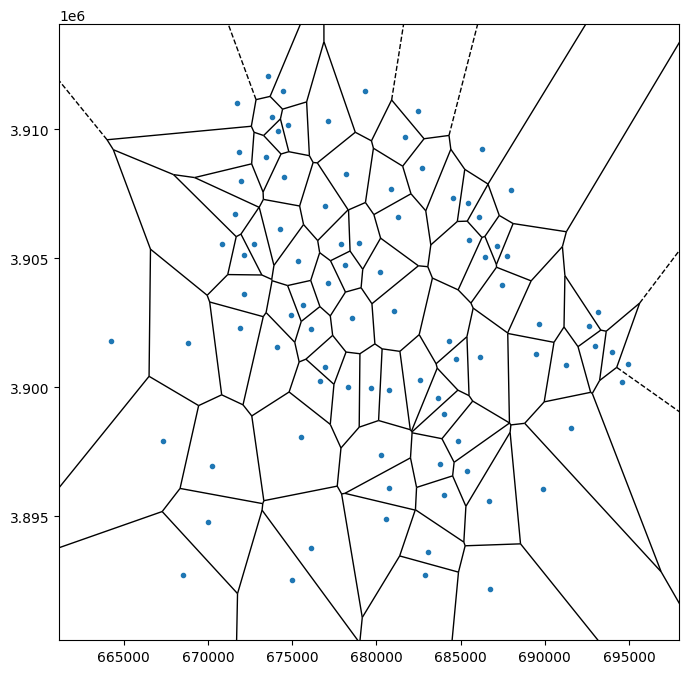

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial import Voronoi, voronoi_plot_2d
import geopandas as gpd
from matplotlib.colors import ListedColormap, BoundaryNorm

sites = pd.read_csv("input_data/sites.csv")
points = sites[["x", "y"]].values
voronoi = Voronoi(points)
fig, ax = plt.subplots(figsize=(8, 8))
voronoi_plot_2d(voronoi, ax=ax, show_vertices=False, line_colors='black')

plt.show()

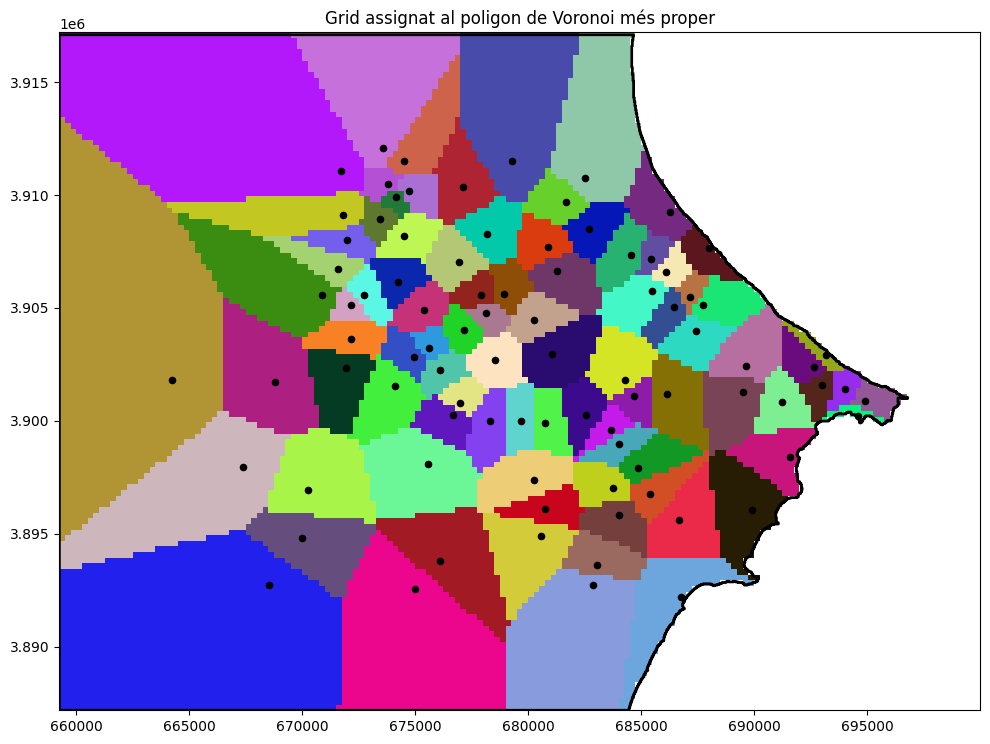

In [3]:
gdf = gpd.read_file("input_data/chebba_clipped.shp")

regular_grid = pd.read_pickle("input_data/regular_grid.pkl")
nx, ny = regular_grid['nx'], regular_grid['ny']

x_grid = np.asarray(regular_grid['x_center']).reshape(ny, nx)
y_grid = np.asarray(regular_grid['y_center']).reshape(ny, nx)
cell_centers = np.column_stack([x_grid.ravel(), y_grid.ravel()])

from scipy.spatial import cKDTree
kdtree = cKDTree(points)
cell_region_index = kdtree.query(cell_centers, k=1)[1].reshape(ny, nx)
regular_grid['voronoi_region'] = cell_region_index*regular_grid['mask']
fig, ax = plt.subplots(figsize=(10, 10))
N = int(np.nanmax(cell_region_index)) + 1
rng = np.random.default_rng(42)
cmap = ListedColormap(rng.random((N, 3)))
norm = BoundaryNorm(np.arange(-0.5, N + 0.5, 1), cmap.N)
mesh = ax.pcolormesh(
    x_grid,
    y_grid,
    regular_grid['voronoi_region'],
    cmap=cmap,
    norm=norm,
    shading="nearest",
)
ax.scatter(points[:, 0], points[:, 1], color='black', s=20, label='Capitals')
ax.set_title('Grid assignat al poligon de Voronoi més proper')
gdf.boundary.plot(ax=ax, color="black", linewidth=2)
plt.tight_layout()
plt.show()

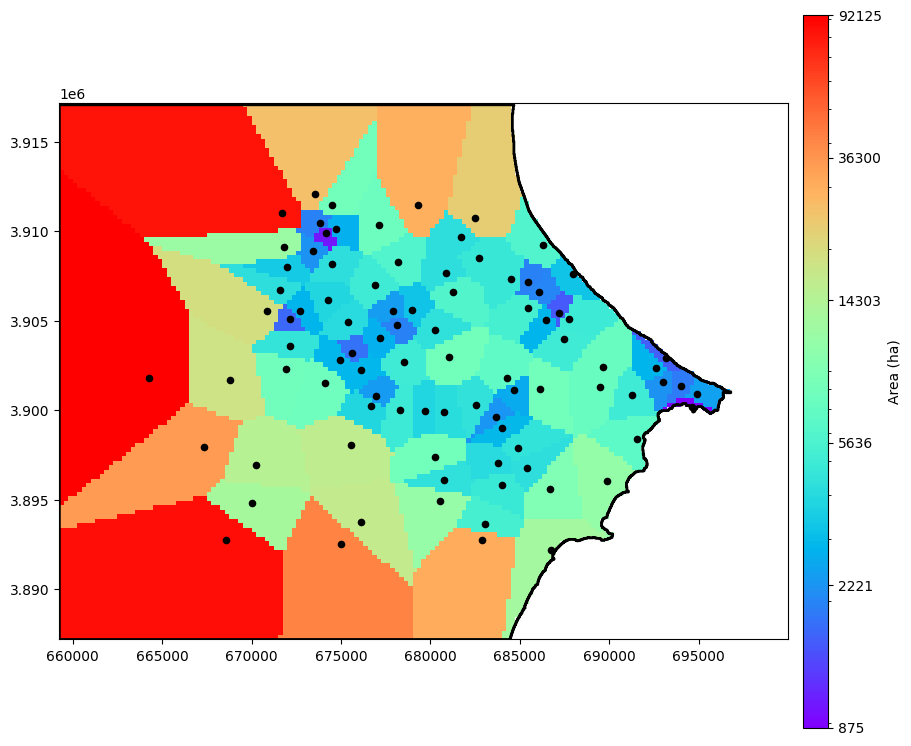

In [4]:
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm

valid_mask = np.asarray(regular_grid['mask']).reshape(ny, nx).astype(bool)
vor_grid = np.asarray(regular_grid['voronoi_region']).reshape(ny, nx).astype(float)

valid_regions = vor_grid[valid_mask]
valid_regions = valid_regions[~np.isnan(valid_regions)].astype(int)

counts = np.bincount(valid_regions, minlength=len(sites))
sites['ncells'] = counts

region_size_grid = counts[cell_region_index].astype(float)
region_size_grid[~valid_mask] = np.nan
region_size_grid = region_size_grid * regular_grid['mask'] * regular_grid['L_cell']**2 / 1e3

finite_vals = region_size_grid[np.isfinite(region_size_grid)]
positive_vals = finite_vals[finite_vals > 0]
vmin = float(positive_vals.min())
vmax = float(positive_vals.max())

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
mesh = ax.pcolormesh(
    x_grid,
    y_grid,
    region_size_grid,
    cmap="rainbow",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    shading="nearest",
)
ax.set_aspect("equal")
ax.scatter(points[:, 0], points[:, 1], color='black', s=20)
gdf.boundary.plot(ax=ax, color="black", linewidth=2)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    label='Area (ha)',
    fraction=0.045,
    pad=0.02,
    shrink=0.9,
    aspect=28,
    anchor=(0.0, 0.5),
)
base_ticks = np.geomspace(vmin, vmax, num=6)
ticks = np.unique(np.concatenate([base_ticks, [vmin, vmax]]))
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" if t < 10 else f"{t:.1f}" if t < 100 else f"{t:.0f}" for t in ticks])

plt.show()
